# Size Estimation in Bins — Using .pkl data

In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import pickle
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.utils.class_weight import compute_class_weight

print(f'TensorFlow: {tf.__version__}')
print(f'TF Hub:     {hub.__version__}')
print(f'GPUs:       {tf.config.list_physical_devices("GPU")}')

c:\Users\jettg\miniconda3\envs\ece228\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


TensorFlow: 2.21.0
TF Hub:     0.16.1
GPUs:       []


## Configuration

In [2]:
TRAIN_PKL = '../data/folds-w-meta.pkl'
TEST_PKL  = '../data/test-w-meta.pkl'

EFFNET_LITE0_URL    = 'https://tfhub.dev/tensorflow/efficientnet/lite0/feature-vector/2'
ESTIMATE_IMAGE_SIZE = (224, 224)   
BATCH_SIZE          = 32
ESTIMATOR_EPOCHS    = 5            # Silva used 5
SEED                = 42

# Train / val / test split
TRAIN_FOLDS = list(range(0, 9))    # folds 0–8 (since not doing 10-fold cross-validation)
VAL_FOLDS   = [9]                  # fold 9

# Size-bin definitions (edges in mm, labels in cm) ─────────────────────────
# Silva et al. original 10-bin layout: 5cm bins up to 40cm, then 10cm bins to 70cm.
BIN_EDGES  = [100, 150, 200, 250, 300, 350, 400, 500, 600, 700]
BIN_LABELS = ['10', '15', '20', '25', '30', '35', '40', '50', '60', '70']
NUM_SIZE_BINS = len(BIN_LABELS)

def length_to_bin(length_mm):
    """Map a length in mm to a size-bin index. Returns None if out of range."""
    for i, edge in enumerate(BIN_EDGES):
        if length_mm <= edge:
            return i
    return None  # fish longer than 700 mm — will be dropped

## Load pkl files

In [3]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='latin1')

train_pkl_folds = load_pkl(TRAIN_PKL)
test_pkl_folds  = load_pkl(TEST_PKL)

print(f'Train pkl folds: {len(train_pkl_folds)}')
print(f'Keys per fold:   {list(train_pkl_folds[0].keys())}')
print(f'Fold 0 size:     {len(train_pkl_folds[0]["data"])} fish')
print(f'Test pkl folds:  {len(test_pkl_folds)}')

Train pkl folds: 10
Keys per fold:   ['fold', 'length', 'weight', 'source', 'girth', 'data', 'id', 'class']
Fold 0 size:     63 fish
Test pkl folds:  1


In [ ]:
fold0 = train_pkl_folds[0]
raw = fold0['data'][0]
print(f'Raw type:  {type(raw)}')
print(f'Raw shape: {np.array(raw).shape}')
print(f'Total elements: {np.array(raw).size}')

Raw type:  <class 'numpy.ndarray'>
Raw shape: (9, 75, 200, 3)
Total elements: 405000


## Convert pkl folds to (image, label) arrays

Each `data` entry is a flattened image; we reshape to `(-1, 200, 3)` to recover RGB pixels, then resize to 224×224 for EfficientNet-Lite0. Entries with missing or out-of-range lengths are dropped (calibration fish, oversized fish).

In [5]:
def folds_to_arrays(folds, fold_indices=None):
    """
    Unpack the listed folds into (N, 224, 224, 3) float32 images and (N,) int bin labels.
    Each fish contributes 9 image entries (one per scanner view).
    """
    if fold_indices is None:
        fold_indices = list(range(len(folds)))
    X, y = [], []
    skipped_fish = 0
    for fi in fold_indices:
        fold = folds[fi]
        for i, raw in enumerate(fold['data']):           # raw: (9, 75, 200, 3)
            length = fold['length'][i]
            if length is None or str(length).strip() in ('', 'NA'):
                skipped_fish += 1; continue
            bin_idx = length_to_bin(float(length))
            if bin_idx is None:
                skipped_fish += 1; continue

            # Each fish has 9 views — emit one example per view
            for view_idx in range(raw.shape[0]):
                img = raw[view_idx].astype(np.float32)   # (75, 200, 3)
                img_resized = tf.image.resize(img, ESTIMATE_IMAGE_SIZE).numpy()
                X.append(img_resized)
                y.append(bin_idx)

    print(f'  Loaded {len(X)} images from {len(X)//9} fish, skipped {skipped_fish} fish')
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

In [6]:
print('Building train set...')
X_train, y_train = folds_to_arrays(train_pkl_folds, TRAIN_FOLDS)
print('Building val set...')
X_val,   y_val   = folds_to_arrays(train_pkl_folds, VAL_FOLDS)
print('Building test set...')
X_test,  y_test  = folds_to_arrays(test_pkl_folds)

print(f'\nTrain: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')
print(f'Train bin counts: {np.bincount(y_train, minlength=NUM_SIZE_BINS)}')
print(f'Val   bin counts: {np.bincount(y_val,   minlength=NUM_SIZE_BINS)}')
print(f'Test  bin counts: {np.bincount(y_test,  minlength=NUM_SIZE_BINS)}')

Building train set...
  Loaded 4788 images from 532 fish, skipped 29 fish
Building val set...
  Loaded 522 images from 58 fish, skipped 4 fish
Building test set...
  Loaded 576 images from 64 fish, skipped 7 fish

Train: 4788  Val: 522  Test: 576
Train bin counts: [   0    0   18   54  108  342  576 1908 1170  612]
Val   bin counts: [  0   0   0   9   9  54  72 180 117  81]
Test  bin counts: [  0   0   0   0  18  18  54 243 180  63]


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(len(X_train), seed=SEED)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))
val_ds   = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
            .batch(BATCH_SIZE).cache().prefetch(AUTOTUNE))
test_ds  = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
            .batch(BATCH_SIZE).cache().prefetch(AUTOTUNE))

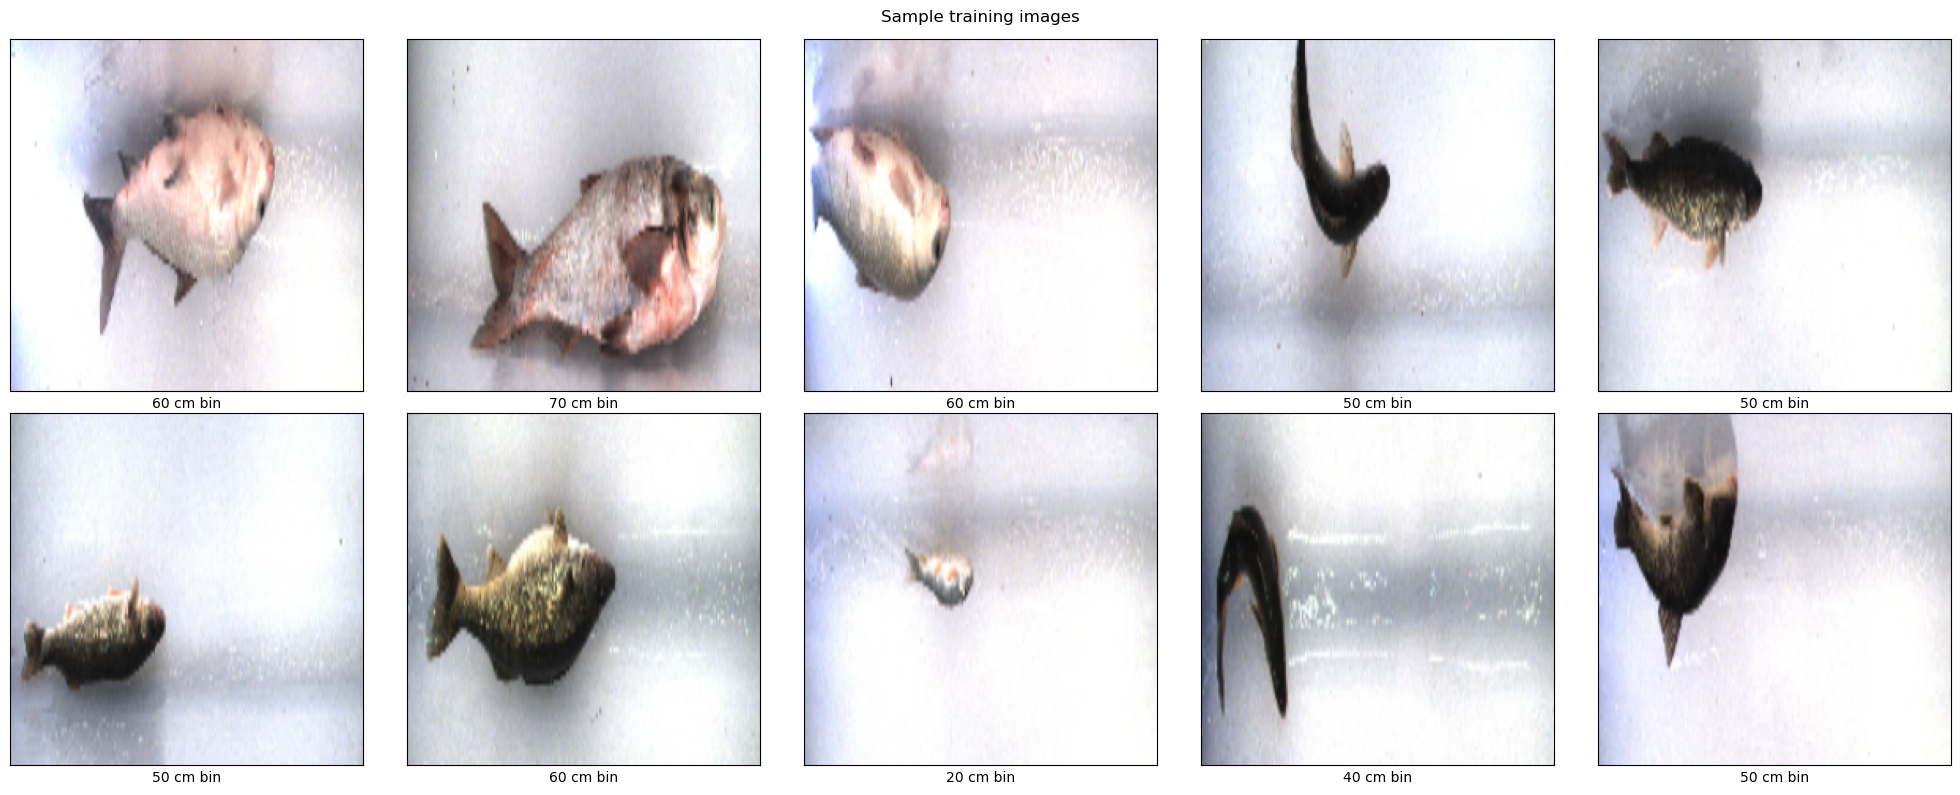

In [8]:
# Preview a few training images
plt.figure(figsize=(20, 8))
for imgs, lbls in train_ds.take(1):
    for i in range(min(10, imgs.shape[0])):
        plt.subplot(2, 5, i + 1)
        plt.xticks([]); plt.yticks([]); plt.grid(False)
        plt.imshow(imgs[i].numpy().astype('uint8'))
        plt.xlabel(f'{BIN_LABELS[lbls[i].numpy()]} cm bin')
plt.suptitle('Sample training images')
plt.tight_layout(); plt.show()

## Build model — EfficientNet-Lite0

In [9]:
def build_estimator(num_classes, trainable_backbone=False):
    backbone = hub.KerasLayer(
        EFFNET_LITE0_URL,
        trainable=trainable_backbone,
        input_shape=ESTIMATE_IMAGE_SIZE + (3,),
    )
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=ESTIMATE_IMAGE_SIZE + (3,)),
        tf.keras.layers.Rescaling(1.0 / 255.0),   # [0,255] → [0,1] for Lite0
        backbone,
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation='softmax'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

estimator = build_estimator(NUM_SIZE_BINS, trainable_backbone=False)
estimator.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 keras_layer (KerasLayer)    (None, 1280)              3413024   
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 10)                12810     
                                                                 
Total params: 3425834 (13.07 MB)
Trainable params: 12810 (50.04 KB)
Non-trainable params: 3413024 (13.02 MB)
_________________________________________________________________


## Train

In [10]:
# Class weights for bin imbalance (small/large fish are rare in Silva's data)
unique_bins = np.unique(y_train)
weights_arr = compute_class_weight('balanced', classes=unique_bins, y=y_train)
class_weights = dict(zip(unique_bins.tolist(), weights_arr.tolist()))
for c in range(NUM_SIZE_BINS):
    class_weights.setdefault(c, 1.0)
print(f'Class weights: {class_weights}')

early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

history = estimator.fit(
    train_ds,
    validation_data=val_ds,
    epochs=ESTIMATOR_EPOCHS
    # Below options not used by Silva but do improve accuracy
    #class_weight=class_weights,
    #callbacks=[early_stop],
)

Class weights: {2: 33.25, 3: 11.083333333333334, 4: 5.541666666666667, 5: 1.75, 6: 1.0390625, 7: 0.3136792452830189, 8: 0.5115384615384615, 9: 0.9779411764705882, 0: 1.0, 1: 1.0}
Epoch 1/5



150/150 [==============================] - 26s 148ms/step - loss: 1.2895 - accuracy: 0.4967 - val_loss: 1.0734 - val_accuracy: 0.5766
Epoch 2/5
150/150 [==============================] - 16s 106ms/step - loss: 0.9236 - accuracy: 0.6445 - val_loss: 0.9718 - val_accuracy: 0.6111
Epoch 3/5
150/150 [==============================] - 16s 106ms/step - loss: 0.8139 - accuracy: 0.6796 - val_loss: 0.9260 - val_accuracy: 0.6245
Epoch 4/5
150/150 [==============================] - 15s 102ms/step - loss: 0.7554 - accuracy: 0.7091 - val_loss: 0.8994 - val_accuracy: 0.6092
Epoch 5/5
150/150 [==============================] - 15s 102ms/step - loss: 0.6965 - accuracy: 0.7281 - val_loss: 0.8681 - val_accuracy: 0.6418


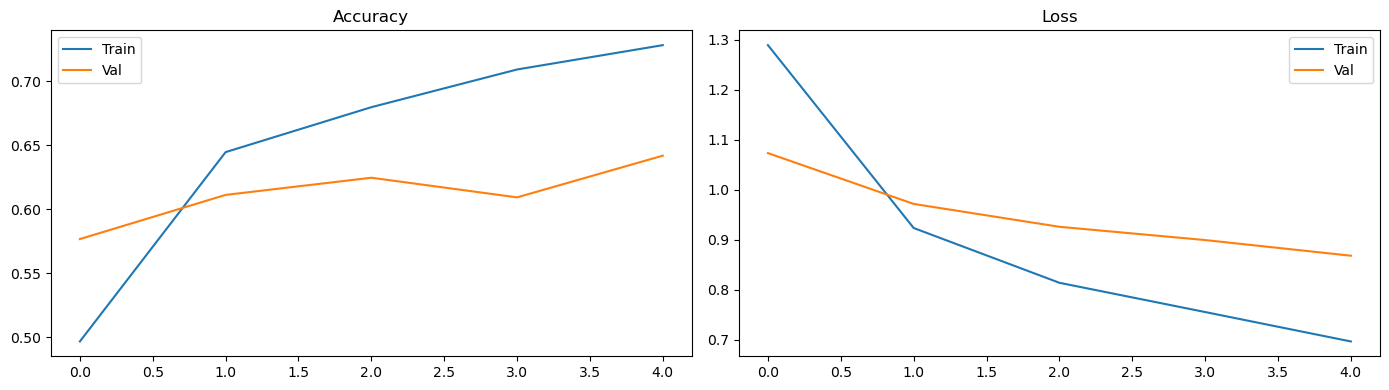

Train  — loss: 0.6203, accuracy: 78.36%
Val    — loss: 0.8681, accuracy: 64.18%
Test   — loss: 0.8491, accuracy: 67.19%


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy'); ax1.legend()
ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss'); ax2.legend()
plt.tight_layout(); plt.show()

for ds, name in [(train_ds, 'Train'), (val_ds, 'Val'), (test_ds, 'Test')]:
    loss, acc = estimator.evaluate(ds, verbose=0)
    print(f'{name:<6} — loss: {loss:.4f}, accuracy: {acc:.2%}')

## Confusion matrix

Per-image accuracy: 67.19%
Per-fish accuracy:  71.88%


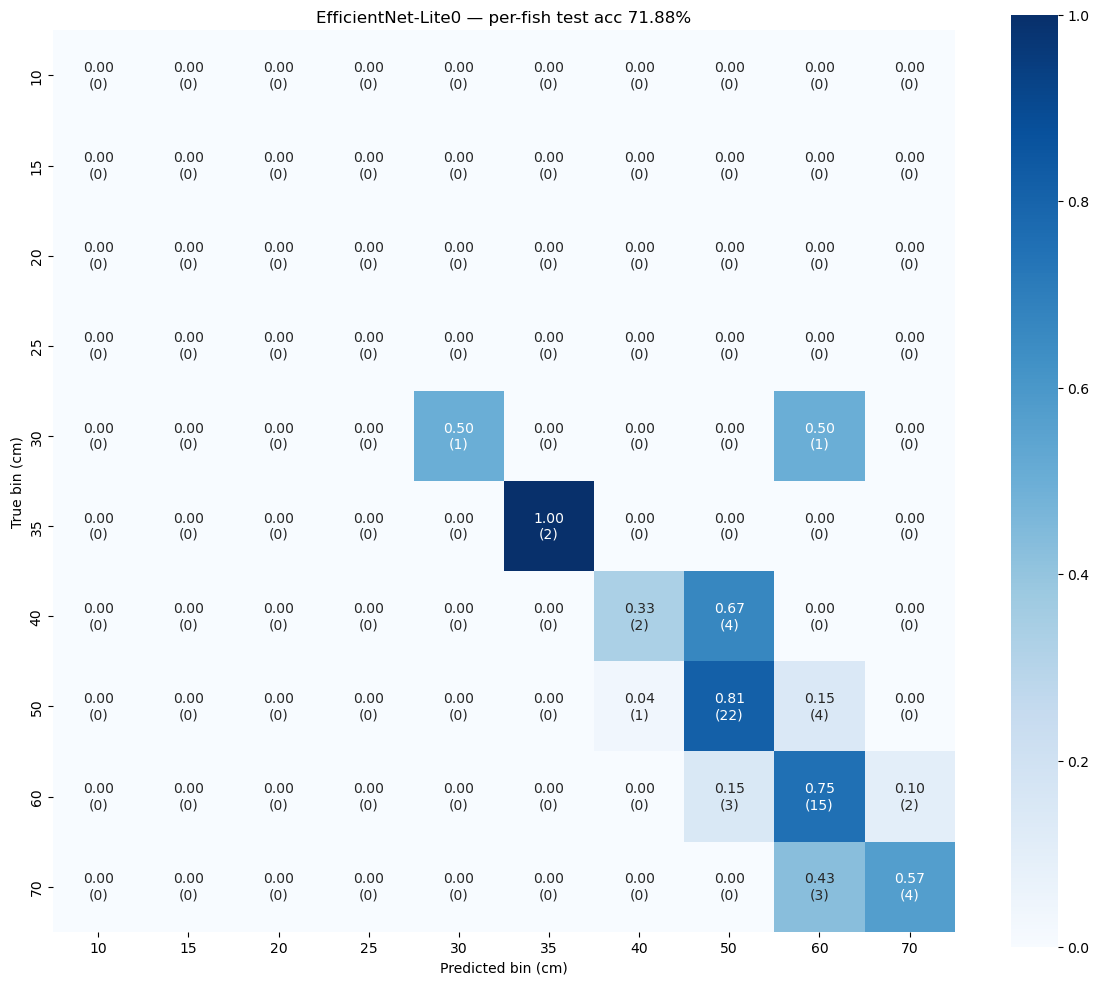

In [12]:
# Per-fish accuracy CM: average the 9 view-level softmaxes per fish

import seaborn as sns
from sklearn.metrics import confusion_matrix

probs = estimator.predict(X_test, verbose=0)
y_pred = np.argmax(probs, axis=1)

per_image_acc = np.mean(y_test == y_pred)
print(f'Per-image accuracy: {per_image_acc:.2%}')

# Per-fish accuracy: average the 9 view-level softmaxes per fish 
probs_per_fish  = probs.reshape(-1, 9, NUM_SIZE_BINS).mean(axis=1)   
y_pred_per_fish = np.argmax(probs_per_fish, axis=1)
y_true_per_fish = y_test.reshape(-1, 9)[:, 0]                       
per_fish_acc    = np.mean(y_pred_per_fish == y_true_per_fish)
print(f'Per-fish accuracy:  {per_fish_acc:.2%}')

# Using per-fish for CM since it's the fairer comparison to Silva (Silva only had 1 image per-fish)
cm      = confusion_matrix(y_true_per_fish, y_pred_per_fish, labels=list(range(NUM_SIZE_BINS)))
row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.where(row_sum == 0, 0, cm.astype('float') / np.where(row_sum == 0, 1, row_sum))
annot   = np.array([[f'{cm_norm[i,j]:.2f}\n({cm[i,j]})' for j in range(NUM_SIZE_BINS)]
                     for i in range(NUM_SIZE_BINS)])

plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, xticklabels=BIN_LABELS, yticklabels=BIN_LABELS,
            cmap='Blues', annot=annot, fmt='', square=True, vmin=0, vmax=1)
plt.title(f'EfficientNet-Lite0 — per-fish test acc {per_fish_acc:.2%}')
plt.ylabel('True bin (cm)'); plt.xlabel('Predicted bin (cm)')
plt.tight_layout(); plt.show()

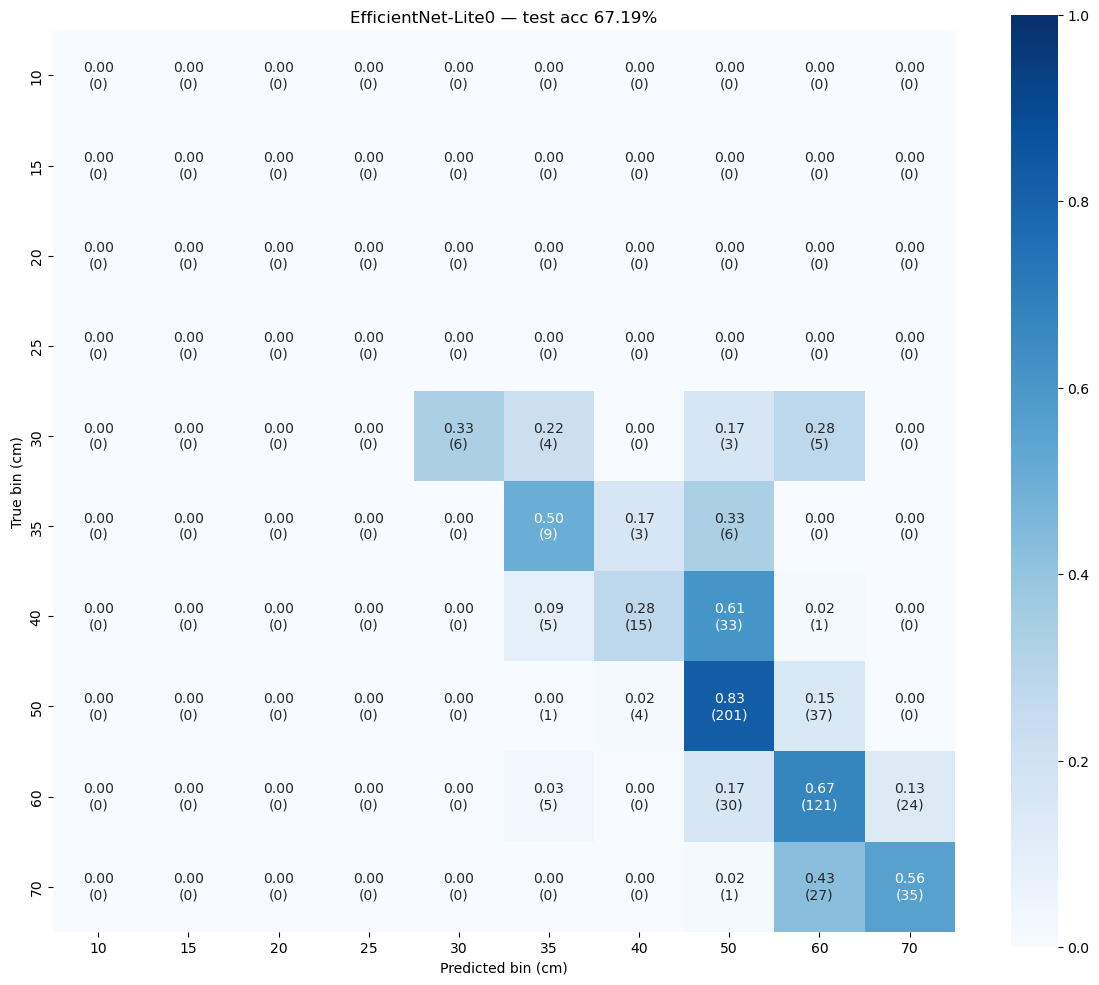

In [13]:
# Per-image predictions

y_pred = np.argmax(estimator.predict(X_test, verbose=0), axis=1)

cm      = confusion_matrix(y_test, y_pred, labels=list(range(NUM_SIZE_BINS)))
row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.where(row_sum == 0, 0, cm.astype('float') / np.where(row_sum == 0, 1, row_sum))
annot   = np.array([[f'{cm_norm[i,j]:.2f}\n({cm[i,j]})' for j in range(NUM_SIZE_BINS)]
                     for i in range(NUM_SIZE_BINS)])

test_acc = np.mean(y_test == y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, xticklabels=BIN_LABELS, yticklabels=BIN_LABELS,
            cmap='Blues', annot=annot, fmt='', square=True, vmin=0, vmax=1)
plt.title(f'EfficientNet-Lite0 — test acc {test_acc:.2%}')
plt.ylabel('True bin (cm)'); plt.xlabel('Predicted bin (cm)')
plt.tight_layout(); plt.show()

In [15]:
SAVE_PATH = './models/estimator_bins.keras'
estimator.save(SAVE_PATH)
print(f'Saved model to {SAVE_PATH}')

Saved model to ./models/estimator_bins.keras
